In [13]:
%matplotlib inline

In [29]:

import pandas as pd
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import datetime
import sys

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
import subprocess

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import scipy.stats as stats

from utils_for_analysis import (
    calculate_ss_for_df_and_factors,
    load_df_all,
    load_df_with_budget,
    discretized_parameter_scale,
    xlabel_dict,
    ylabel_dict,
    title_fontsize,
    label_fontsize,
    tick_fontsize,
    legend_fontsize,
    original_parameter_scale,
    color_map,
    fix_ticks,
    get_labels,
    num_muts_column_name,
    DATASET_PATHS
)

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'code')))
from example_run_jobs import *

plt.rcParams['svg.fonttype'] = 'none'

In [30]:



subsamples_df_all = []
for k,v in DATASET_PATHS.items():
    path = os.path.join(os.getcwd(), "/".join(v.split("/")[0:-1]) + "/regression_result_by_training_samples.csv")
    print(path)

    if os.path.exists(path):
        df = pd.read_csv(path)

        # Identify the cor_X column (the one that is not 'cor_ohe')
        cor_x_col = [col for col in df.columns if col.startswith('cor_') and col != 'cor_ohe'][0]
        shuffled_cor_x_col = [col for col in df.columns if col.startswith('shuffled_cor_') and col != 'shuffled_cor_ohe'][0]

        # Melt the DataFrame to long format
        melted = pd.DataFrame()

        # OHE, not shuffled
        ohe_not_shuf = df[['N_samples', 'iter', 'cor_ohe']].copy()
        ohe_not_shuf['dataset'] = k
        ohe_not_shuf['value'] = ohe_not_shuf['cor_ohe']
        ohe_not_shuf['group'] = "OHE"
        ohe_not_shuf['shuffle'] = False
        ohe_not_shuf['statistic_type'] = "Correlation"
        ohe_not_shuf = ohe_not_shuf[['N_samples', 'iter', 'dataset', 'value', 'group', 'shuffle', 'statistic_type']]

        # PLM, not shuffled
        plm_not_shuf = df[['N_samples', 'iter', cor_x_col]].copy()
        plm_not_shuf['dataset'] = k
        plm_not_shuf['value'] = plm_not_shuf[cor_x_col]
        plm_not_shuf['group'] = "PLM"
        plm_not_shuf['shuffle'] = False
        plm_not_shuf['statistic_type'] = "Correlation"
        plm_not_shuf = plm_not_shuf[['N_samples', 'iter', 'dataset', 'value', 'group', 'shuffle', 'statistic_type']]

        # OHE, shuffled
        ohe_shuf = df[['N_samples', 'iter', 'shuffled_cor_ohe']].copy()
        ohe_shuf['dataset'] = k
        ohe_shuf['value'] = ohe_shuf['shuffled_cor_ohe']
        ohe_shuf['group'] = "OHE"
        ohe_shuf['shuffle'] = True
        ohe_shuf['statistic_type'] = "Correlation"
        ohe_shuf = ohe_shuf[['N_samples', 'iter', 'dataset', 'value', 'group', 'shuffle', 'statistic_type']]

        # PLM, shuffled
        plm_shuf = df[['N_samples', 'iter', shuffled_cor_x_col]].copy()
        plm_shuf['dataset'] = k
        plm_shuf['value'] = plm_shuf[shuffled_cor_x_col]
        plm_shuf['group'] = "PLM"
        plm_shuf['shuffle'] = True
        plm_shuf['statistic_type'] = "Correlation"
        plm_shuf = plm_shuf[['N_samples', 'iter', 'dataset', 'value', 'group', 'shuffle', 'statistic_type']]

        # Concatenate all sub-dfs
        df = pd.concat([ohe_not_shuf, plm_not_shuf, ohe_shuf, plm_shuf], ignore_index=True)
        print(df.head())
        subsamples_df_all.append(df)
    else:
        print("File does not exist")




final_df = pd.concat(subsamples_df_all)


/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/regression_result_by_training_samples.csv
File does not exist
/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/regression_result_by_training_samples.csv
   N_samples  iter dataset     value group  shuffle statistic_type
0         10     0     lov  0.246480   OHE    False    Correlation
1         10     1     lov  0.104840   OHE    False    Correlation
2         10     2     lov  0.206681   OHE    False    Correlation
3         10     3     lov  0.448608   OHE    False    Correlation
4         10     4     lov  0.301030   OHE    False    Correlation
/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/regression_result_by_training_samples.csv
   N_samples  iter dataset     value group  shuffle statistic_type
0         10     0   pard3  0.471079   OHE    False    Correlation
1         10     1   pard3  0.263856   OHE    False    Correlation
2     

In [32]:



path = os.path.join(os.getcwd(), "data/gfp/subsample_classification_results/")


features_to_use = _dict = ["roc", "precision", "f1", "accuracy", "recall", "top_100_pct"]
subsamples_df_all_gfp = []
for file in os.listdir(path):

    ohe_or_llm = file.startswith("llm")

    df = pd.read_csv(os.path.join(path, file))

    for feature in features_to_use:
        sub_df = df[["sample_size", "iter", feature, "shuffle"]].copy()
        sub_df.columns = ["N_samples", "iter", "value", "shuffle"]
        
        sub_df["shuffle"] = (sub_df["shuffle"] == "shuffled").astype(bool)
        sub_df['dataset'] = "gfp"
        sub_df["group"] = "PLM" if ohe_or_llm else "OHE"
        sub_df["statistic_type"] = feature
        
        sub_df = sub_df[['N_samples', 'iter', 'dataset', 'value', 'group', 'shuffle', 'statistic_type']]
        

        subsamples_df_all_gfp.append(sub_df)


gfp_final_df = pd.concat(subsamples_df_all_gfp)


In [110]:
final_df_all = pd.concat([final_df, gfp_final_df[gfp_final_df["N_samples"] >= 100]])
final_df_all = final_df_all[~((final_df_all["dataset"] == "gfp") & (final_df_all["statistic_type"] == "precision"))]
#final_df_all = final_df_all[~((final_df_all["dataset"] == "lov") & (final_df_all["N_samples"] == 5000))]
final_df_all.loc[final_df_all["dataset"] == "gfp", "dataset"] = "GFP"
final_df_all.loc[final_df_all["dataset"] == "pard3", "dataset"] = "PARD3"
final_df_all.loc[final_df_all["dataset"] == "nmt", "dataset"] = "NMT"
final_df_all.loc[final_df_all["dataset"] == "gcn4", "dataset"] = "GCN4"
final_df_all.loc[final_df_all["dataset"] == "pte", "dataset"] = "PTE"
final_df_all.loc[final_df_all["dataset"] == "lov", "dataset"] = "LOV"

In [104]:
final_df_all[(final_df_all["dataset"] == "LOV")].N_samples.unique()

array([   10,    25,    50,   100,   250,   500,  1000,  2500,  5000,
       10000])

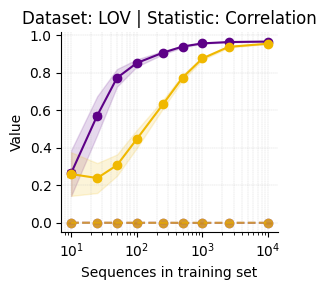

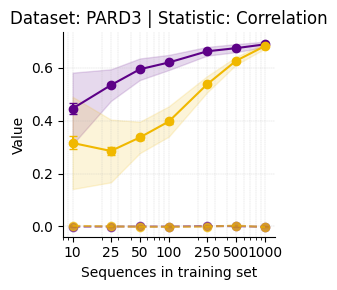

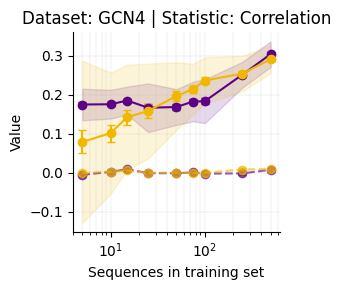

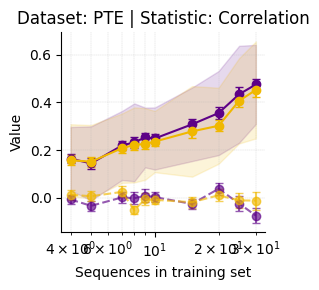

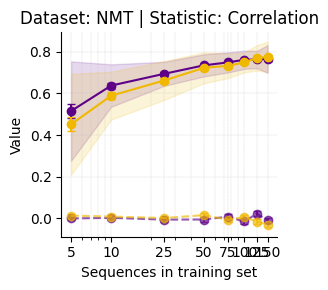

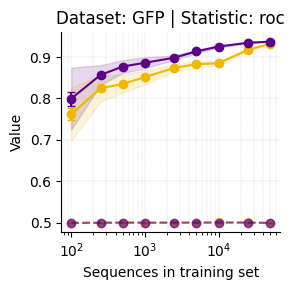

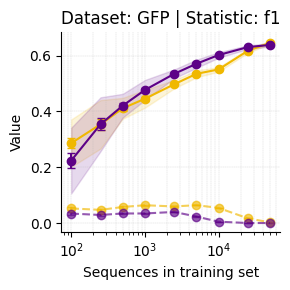

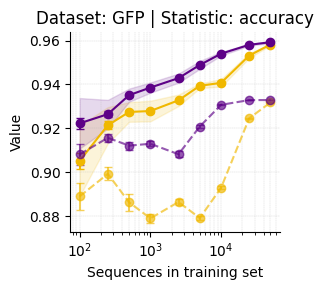

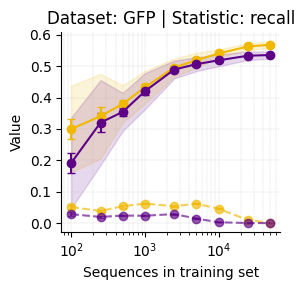

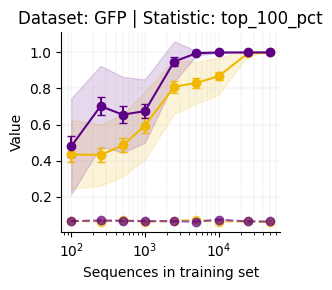

In [107]:

# Use the custom color map for OHE/PLM as defined in classifier_over_embeddings.ipynb
color_map = {
    "PLM": "#f0b800",
    "OHE": "#5d0187",
}

datasets = final_df_all["dataset"].unique()
statistic_types = final_df_all["statistic_type"].unique()

# Plot each dataset separately, not in subplots
#plot_datasets = datasets[:5] if len(datasets) > 5 else datasets

for i, dataset in enumerate(datasets):
    for statistic_type in statistic_types:
        sub_df = final_df_all[(final_df_all["dataset"] == dataset) & (final_df_all["statistic_type"] == statistic_type)]
        if sub_df.empty:
            continue

        if dataset == "gcn4" or dataset == "nmt":
            sub_df["value"] = np.abs(sub_df["value"])

        plt.figure(figsize=(3, 3))
        for group in sub_df['group'].unique():
            # Use color from the map, fallback to default if group not defined
            base_color = color_map.get(group, None)
            for shuffle in [False, True]:
                _df = sub_df[(sub_df['group'] == group) & (sub_df['shuffle'] == shuffle)]
                if _df.empty:
                    continue
                grouped = _df.groupby('N_samples')['value']
                avg = grouped.mean()
                std = grouped.std()
                sem = grouped.sem()
                n_samples = avg.index.values
                linestyle = '-' if not shuffle else '--'
                label = f'{group}{" (shuffled)" if shuffle else ""}'

                # Set color depending on group; for shuffled use lower alpha
                color = base_color
                if color is None:
                    color = None # Let matplotlib auto-assign if not provided
                alpha = 1.0 if not shuffle else 0.65

                # Plot with error bars (SEM)
                plt.errorbar(
                    n_samples, avg.values, yerr=sem.values,
                    fmt=linestyle, capsize=3, label=label, marker='o',
                    color=color, alpha=alpha
                )

                if not shuffle:
                    plt.fill_between(
                        n_samples, avg.values - std.values, avg.values + std.values,
                        alpha=0.15 if not shuffle else 0.09, color=color
                    )

        plt.title(f'Dataset: {dataset} | Statistic: {statistic_type}')
        plt.xlabel('Sequences in training set')
        plt.ylabel('Value')
        plt.xscale('log')

        # Dynamically set x-ticks if few values
        all_ticks = sorted(sub_df['N_samples'].unique())
        if len(all_ticks) <= 8:
            plt.xticks(all_ticks, [str(x) for x in all_ticks])

        plt.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
        ax = plt.gca()
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

        #plt.legend()
        plt.tight_layout()
        #plt.show()

Number of ratio values more than 4 stds from the mean: 9
########################
1.4659383862703579
1.2104572963702362
0.6382188213781846
46.59383862703578
21.045729637023626
63.82188213781846
########################
Number of ratio values more than 4 stds from the mean: 3
########################
1.5208493487152046
1.3098432222881016
0.6557168103723684
52.08493487152046
30.984322228810157
65.57168103723683
########################
Number of ratio values more than 4 stds from the mean: 7
########################
1.5919003090180421
0.9651171808421831
2.211667545186507
59.19003090180421
-3.488281915781688
221.1667545186507
########################
Number of ratio values more than 4 stds from the mean: 9
########################
1.1269060690506583
1.004532064355314
1.1352876695388938
12.690606905065819
0.4532064355313947
113.52876695388937
########################
Number of ratio values more than 4 stds from the mean: 8
########################
1.0337946391338266
1.0169852801352417
0.14

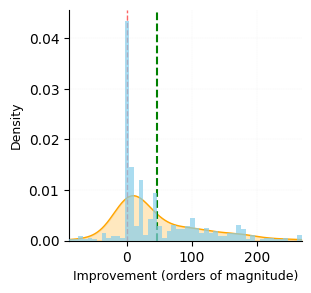

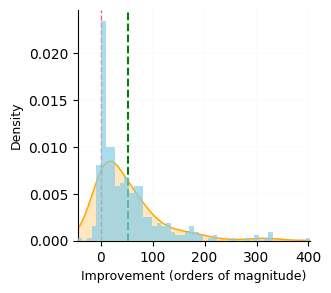

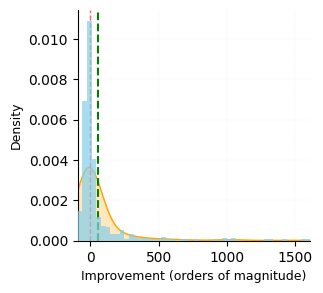

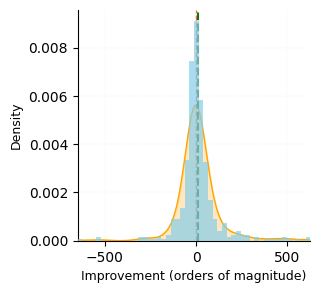

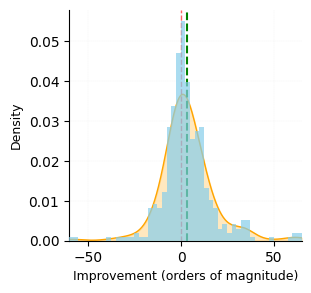

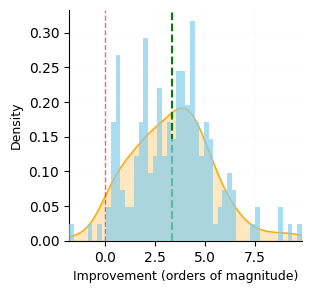

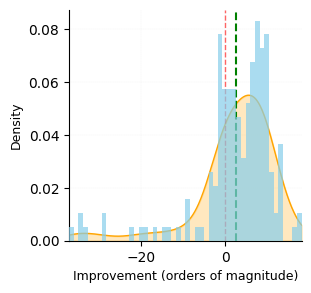

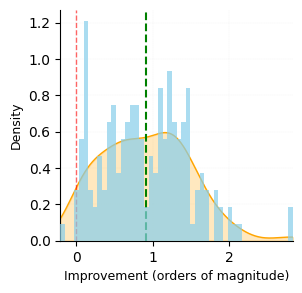

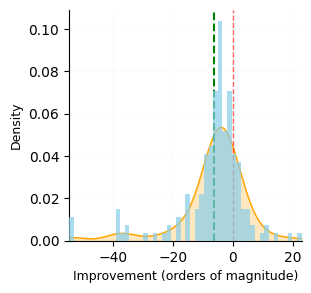

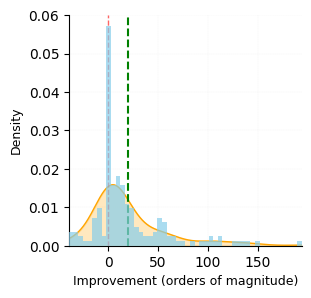

In [73]:

df_for_error_bars = []


for i, dataset in enumerate(datasets):
    for statistic_type in statistic_types:
        sub_df = final_df_all[(final_df_all["dataset"] == dataset) & 
                              (final_df_all["statistic_type"] == statistic_type) & 
                              (final_df_all["shuffle"] == False)]
        if sub_df.empty:
            continue


        ohe_values_df = sub_df[sub_df["group"] == "OHE"]
        plm_values_df = sub_df[sub_df["group"] == "PLM"]

        ohe_values_df_sorted = ohe_values_df.sort_values(["N_samples", "iter"])
        plm_values_df_sorted = plm_values_df.sort_values(["N_samples", "iter"])


        assert sum(ohe_values_df_sorted["iter"].to_numpy() == plm_values_df_sorted["iter"].to_numpy()) == len(ohe_values_df_sorted)
        assert sum(ohe_values_df_sorted["N_samples"].to_numpy() == plm_values_df_sorted["N_samples"].to_numpy()) == len(ohe_values_df_sorted)

        plm_values = plm_values_df_sorted["value"].to_numpy()
        ohe_values = ohe_values_df_sorted["value"].to_numpy()

        ohe_values = ohe_values[plm_values != 0]
        plm_values = plm_values[plm_values != 0]
        


        if dataset == "GCN4" or dataset == "NMT":
            ratio = np.abs(ohe_values) / np.abs(plm_values)
        else:
            ratio = ohe_values / plm_values

        # Remove values more than 4 std deviations from the mean in ratio and print their count
        ratio_mean = np.mean(ratio)
        ratio_std = np.std(ratio)
        outlier_mask = np.abs(ratio - ratio_mean) > (3 * ratio_std)
        num_outliers = np.sum(outlier_mask)
        print(f"Number of ratio values more than 4 stds from the mean: {num_outliers}")
        ratio = ratio[~outlier_mask]
        ohe_values = ohe_values[~outlier_mask]
        plm_values = plm_values[~outlier_mask]
        statistic = (ratio - 1) * 100


        #statistic = (np.log10(np.abs(ratio) + 10 ** -8))  * ((ratio > 0).astype(int) - (ratio < 0).astype(int))
        #statistic = (ratio - 1) * 100
        #statistic = np.log10(np.abs(ratio) + 10 ** -8)
        #statistic = #np.log10(ratio + 10 ** -8)
        
        
        print("########################")
        print(np.mean(ratio))
        print(np.median(ratio))
        print(np.std(ratio))
        print(np.mean(statistic))
        print(np.median(statistic))
        print(np.std(statistic))
        print("########################")


        df_for_error_bars.append({
            "dataset": dataset,
            "statistic_type": statistic_type,
            "statistic": statistic,
            "ratio": ratio,
            "mean_ratio": np.mean(ratio),
            "std_ratio": np.std(ratio),
            "sem_ratio": np.std(ratio) / np.sqrt(len(ratio)),
            "mean": np.mean(statistic),
            "std": np.std(statistic),
            "sem": np.std(statistic) / np.sqrt(len(statistic)),
            "ohe_values": ohe_values,
            "plm_values": plm_values,
        })

        plt.figure(figsize=(3, 3))
        ax = plt.gca()
        # Plot histogram
        counts, bins, patches = ax.hist(
            statistic, bins=50, color='skyblue', alpha=0.7, density=True, label='Histogram',
            zorder=3
        )

        # Plot KDE
        if len(statistic) > 1:
            xmin, xmax = bins[0], bins[-1]
            x = np.linspace(xmin, xmax, 500)
            kde = stats.gaussian_kde(statistic, bw_method=0.4)
            y = kde(x)
            ax.plot(x, y, color='orange', linewidth=1, label='Density (KDE)', zorder=2)
            ax.fill_between(x, y, color='orange', alpha=0.25, zorder=2)
        else:
            xmin, xmax = ax.get_xlim()

        # Add mean line
        mean_val = np.mean(statistic)
        ax.axvline(mean_val, color='green', linestyle='--', label=f'Mean = {mean_val:.2f}')
        ax.axvline(0, color="red", linestyle="--", lw=1, alpha=0.6, label="No Improvement")
        ax.set_ylabel("Density", fontsize=9)    
        ax.set_xlabel("Improvement (orders of magnitude)", fontsize=9)
        ax.set_xlim(xmin, xmax)
        # fix_ticks(ax, 
        #         y=True,
        #         x=False,
        #         every_other=False,
        #         fontsize=8)
        
        # fix_ticks(ax, 
        #         y=False,
        #         x=True,
        #         every_other=False,
        #         xlim=[xmin,xmax],
        #         fontsize=8)

        plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.grid(alpha=0.2)
        #plt.xscale("log")




std_error_bars_df = pd.DataFrame(df_for_error_bars)


Number of ratio values more than 4 stds from the mean: 4
########################
1.033416579475649
1.0344810364650932
0.019917226260122708
3.3416579475649013
3.448103646509315
1.9917226260122705
########################
Number of ratio values more than 4 stds from the mean: 5
########################
1.0253240005489284
1.0438884418016532
0.0938208355028017
2.532400054892821
4.388844180165319
9.382083550280168
########################
Number of ratio values more than 4 stds from the mean: 3
########################
1.009084541885472
1.0087980045762819
0.005661374596442824
0.9084541885471908
0.8798004576281881
0.5661374596442824
########################
Number of ratio values more than 4 stds from the mean: 6
########################
0.9356567717161033
0.9538001509507728
0.11377503619827804
-6.434322828389667
-4.6199849049227195
11.377503619827802
########################
Number of ratio values more than 4 stds from the mean: 4
########################
1.1985316018661012
1.0752688172043

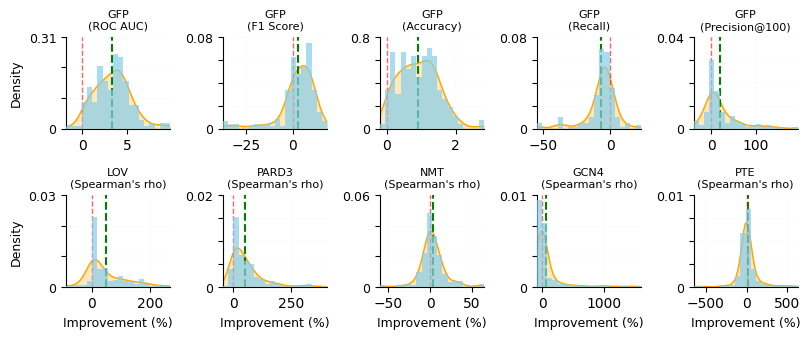

In [111]:

df_for_error_bars = []

# Prepare combinations for subplots
plot_pairs = []
for dataset in ["GFP", "LOV", "PARD3", "NMT", "GCN4", "PTE"]:
    for statistic_type in ["roc", "f1", "accuracy", "recall", "top_100_pct", "Correlation"]:
        sub_df = final_df_all[(final_df_all["dataset"] == dataset) &
                              (final_df_all["statistic_type"] == statistic_type) &
                              (final_df_all["shuffle"] == False)]

        if len(sub_df) > 0:
            plot_pairs.append((dataset, statistic_type, sub_df))
        else:
            continue

nplots = len(plot_pairs)
ncols = 5
nrows = int(np.ceil(nplots / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.2, 3.5))
axes = axes.flatten()

for i, (dataset, statistic_type, sub_df) in enumerate(plot_pairs):
    if sub_df.empty:
        continue

    ohe_values_df = sub_df[sub_df["group"] == "OHE"]
    plm_values_df = sub_df[sub_df["group"] == "PLM"]

    ohe_values_df_sorted = ohe_values_df.sort_values(["N_samples", "iter"])
    plm_values_df_sorted = plm_values_df.sort_values(["N_samples", "iter"])

    # Make sure we compare same samples/iterations
    assert sum(ohe_values_df_sorted["iter"].to_numpy() == plm_values_df_sorted["iter"].to_numpy()) == len(ohe_values_df_sorted)
    assert sum(ohe_values_df_sorted["N_samples"].to_numpy() == plm_values_df_sorted["N_samples"].to_numpy()) == len(ohe_values_df_sorted)

    plm_values = plm_values_df_sorted["value"].to_numpy()
    ohe_values = ohe_values_df_sorted["value"].to_numpy()

    ohe_values = ohe_values[plm_values != 0]
    plm_values = plm_values[plm_values != 0]

    if dataset == "GCN4" or dataset == "NMT":
        ratio = np.abs(ohe_values) / np.abs(plm_values)
    else:
        ratio = ohe_values / plm_values

    # Remove values more than 4 std deviations from the mean in ratio and print their count
    ratio_mean = np.mean(ratio)
    ratio_std = np.std(ratio)
    outlier_mask = np.abs(ratio - ratio_mean) > (3 * ratio_std)
    num_outliers = np.sum(outlier_mask)
    print(f"Number of ratio values more than 4 stds from the mean: {num_outliers}")
    ratio = ratio[~outlier_mask]
    ohe_values = ohe_values[~outlier_mask]
    plm_values = plm_values[~outlier_mask]
    statistic = (ratio - 1) * 100

    # Optional: Additional statistics printout
    print("########################")
    print(np.mean(ratio))
    print(np.median(ratio))
    print(np.std(ratio))
    print(np.mean(statistic))
    print(np.median(statistic))
    print(np.std(statistic))
    print("########################")

    df_for_error_bars.append({
        "dataset": dataset,
        "statistic_type": statistic_type,
        "statistic": statistic,
        "ratio": ratio,
        "mean_ratio": np.mean(ratio),
        "std_ratio": np.std(ratio),
        "sem_ratio": np.std(ratio) / np.sqrt(len(ratio)),
        "mean": np.mean(statistic),
        "std": np.std(statistic),
        "sem": np.std(statistic) / np.sqrt(len(statistic)),
        "ohe_values": ohe_values,
        "plm_values": plm_values,
    })

    ax = axes[i]
    # Plot histogram
    counts, bins, patches = ax.hist(
        statistic, bins=20, color='skyblue', alpha=0.7, density=True, label='Histogram',
        zorder=3
    )

    # Plot KDE
    if len(statistic) > 1:
        xmin, xmax = bins[0], bins[-1]
        x = np.linspace(xmin, xmax, 500)
        kde = stats.gaussian_kde(statistic, bw_method=0.4)
        y = kde(x)
        ax.plot(x, y, color='orange', linewidth=1, label='Density (KDE)', zorder=2)
        ax.fill_between(x, y, color='orange', alpha=0.25, zorder=2)
    else:
        xmin, xmax = ax.get_xlim()

    # Add mean line
    mean_val = np.mean(statistic)
    ax.axvline(mean_val, color='green', linestyle='--', label=f'Mean = {mean_val:.2f}')
    ax.axvline(0, color="red", linestyle="--", lw=1, alpha=0.6, label="No Improvement")
    IST = statistic_type.lower()
    ax.set_title(f"{dataset}\n({ylabel_dict[IST]})", fontsize=8)

    if i == 0 or i % ncols == 0:
        ax.set_ylabel("Density", fontsize=9)
    else:
        ax.set_ylabel("")
    if i >= ncols * (nrows - 1):
        ax.set_xlabel("Improvement (%)", fontsize=9)
    else:
        ax.set_xlabel("")
    ax.set_xlim(xmin, xmax)

    # Optionally fix ticks here if you have a fix_ticks utility function
    fix_ticks(ax, y=True, x=False, every_other=False, fontsize=9)
    #fix_ticks(ax, y=False, x=True, every_other=False, xlim=[xmin, xmax], fontsize=9)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(alpha=0.2, linestyle='--', linewidth=0.25)

# Turn off extra axes (if any)
for j in range(len(plot_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("./refined_figures/figure_ohe_vs_llm/improvement_by_statistic_type_subplot.svg", bbox_inches='tight')
plt.show()

std_error_bars_df = pd.DataFrame(df_for_error_bars)



In [ ]:
final_df_all.statistic_type.unique()

array(['Correlation', 'roc', 'f1', 'accuracy', 'recall', 'top_100_pct'],
      dtype=object)

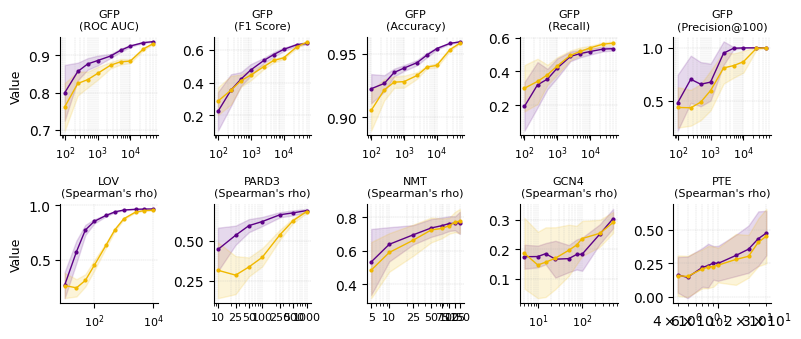

In [112]:

# --- Compute the plot_pairs in a specific order as above (see top cell context) ---
# Use the same order of datasets and statistic_types as in the subplot/histogram above
ordered_datasets = ["GFP", "LOV", "PARD3", "NMT", "GCN4", "PTE"]
ordered_statistic_types = ["roc", "f1", "accuracy", "recall", "top_100_pct", "Correlation"]

color_map = {
    "PLM": "#f0b800",
    "OHE": "#5d0187",
}

# Rather than plotting with plt.figure, do subplots like the main plot above for consistency:
plot_pairs = []
for dataset in ordered_datasets:
    for statistic_type in ordered_statistic_types:
        sub_df = final_df_all[(final_df_all["dataset"] == dataset) & 
                              (final_df_all["statistic_type"] == statistic_type)]
        if len(sub_df) > 0:
            plot_pairs.append((dataset, statistic_type, sub_df))

nplots = len(plot_pairs)
ncols = 5  # Same as @file_context_0 
nrows = int(np.ceil(nplots / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.2, 3.5))
axes = axes.flatten()

for i, (dataset, statistic_type, sub_df) in enumerate(plot_pairs):
    if sub_df.empty:
        continue

    ax = axes[i]

    # Value transform for gcn4/nmt
    if dataset.lower() == "gcn4" or dataset.lower() == "nmt":
        sub_df = sub_df.copy()
        sub_df["value"] = np.abs(sub_df["value"])

    # Plot each group (OHE/PLM), both shuffled and not shuffled
    for group in ['OHE', 'PLM']:
        base_color = color_map.get(group, None)
        for shuffle in [False]:
            _df = sub_df[(sub_df['group'] == group) & (sub_df['shuffle'] == shuffle)]
            if _df.empty:
                continue
            grouped = _df.groupby('N_samples')['value']
            avg = grouped.mean()
            std = grouped.std()
            sem = grouped.sem()
            n_samples = avg.index.values
            linestyle = '-' if not shuffle else '--'
            label = f'{group}{" (shuffled)" if shuffle else ""}'

            # Set color depending on group; for shuffled use lower alpha
            color = base_color
            if color is None:
                color = None  # Let matplotlib auto-assign if not provided
            alpha = 1.0 if not shuffle else 0.65

            # Plot with error bars (SEM)
            ax.errorbar(
                n_samples, avg.values,
                fmt=linestyle, capsize=3, label=label, marker='o',
                markersize=2,
                color=color, alpha=alpha, lw=1
            )

            if not shuffle:
                ax.fill_between(
                    n_samples, avg.values - std.values, avg.values + std.values,
                    alpha=0.15, color=color
                )

    IST = statistic_type.lower()
    ax.set_title(f"{dataset}\n({ylabel_dict[IST]})", fontsize=8)
    if i == 0 or i % ncols == 0:
        ax.set_ylabel("Value", fontsize=9)
    else:
        ax.set_ylabel("")
    ax.set_xscale('log')

    # Dynamically set x-ticks if few values
    all_ticks = sorted(sub_df['N_samples'].unique())
    if len(all_ticks) <= 8:
        ax.set_xticks(all_ticks)
        ax.set_xticklabels([str(x) for x in all_ticks], fontsize=8)
    else:
        ax.tick_params(axis='x', labelsize=8)

    ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Optionally fix ticks utility (if available)
    #fix_ticks(ax, y=True, x=False, every_other=False, fontsize=9)


# Turn off extra axes
for j in range(len(plot_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("./refined_figures/figure_ohe_vs_llm/ohe_plm_metrics_by_dataset_statistic_subplot.svg", bbox_inches='tight')
plt.show()


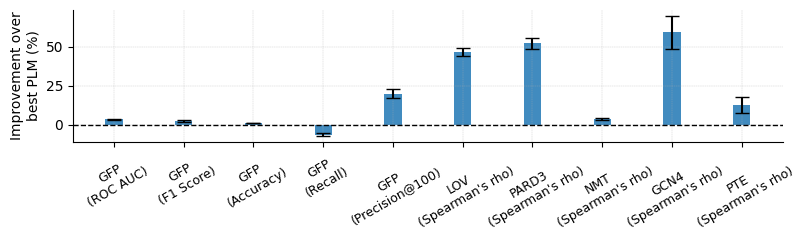

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# Assume std_error_bars_df has columns: dataset, statistic_type, mean, sem, statistic

fig, ax = plt.subplots(figsize=(8.2, 2.5))

# Build x locations and labels (one for each row)
x_labels = [
    f"{row['dataset']}\n({ylabel_dict[row['statistic_type'].lower()]})"
    for _, row in std_error_bars_df.iterrows()
]
x = np.arange(len(std_error_bars_df))

# Plot barplot of means with error bars (sem)
bars = ax.bar(
    x, std_error_bars_df["mean"],
    yerr=std_error_bars_df["sem"],
    color="C0", alpha=0.85, capsize=5, width=0.25,
    ecolor="black",
    label="Mean ± SEM"
)

# # # Optionally overlay all observations as scatter (dotplot) for each group
# for i, (_, row) in enumerate(std_error_bars_df.iterrows()):
#     if isinstance(row["statistic"], (list, np.ndarray)):
#         n = len(row["statistic"])
#         # jitter x
#         jittered_x = np.random.normal(loc=x[i], scale=0.09, size=n)
#         ax.scatter(
#             jittered_x, row["statistic"],
#             color="black", s=13, alpha=0.5, lw=0, zorder=2
#         )

# Style the plot as reference
tick_locations = x
plt.grid(True, which='major', linestyle='--', linewidth=0.3, alpha=0.7)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(tick_locations, x_labels, rotation=30, ha='center', fontsize=9)
plt.ylabel("Improvement over\nbest PLM (%)", fontsize=10)
plt.xlabel("")
#plt.yscale("log")

plt.axhline(0, color='k', linestyle='dashed', lw=1)
plt.tight_layout()
plt.savefig("./refined_figures/figure_ohe_vs_llm/summarized_improvement_by_statistic_type.svg", bbox_inches='tight')
plt.show()


In [ ]:
std_error_bars_df

In [ ]:



plt.hist(ohe_values_df_sorted["value"] / plm_values_df_sorted["value"])

In [ ]:
sub_df